# Logistic Regression on IRIS Dataset

## Objective
To understand and implement **Logistic Regression** on the **IRIS dataset** for flower species classification.

## What this notebook covers
- Load and understand the IRIS dataset
- Prepare features and target variable
- Split data into training and testing sets
- Train Logistic Regression model
- Make predictions
- Evaluate model using accuracy, confusion matrix, and classification report
- Understand feature importance through coefficients

## Dataset Brief
The IRIS dataset contains measurements of flowers from **3 species**:
- Setosa
- Versicolor
- Virginica

### Input Features
- Sepal Length
- Sepal Width
- Petal Length
- Petal Width

### Output
- Species of flower

In [1]:
# Import required libraries
# pandas is used to work with tabular data
import pandas as pd

# numpy is used for numerical operations
import numpy as np

# matplotlib and seaborn are used for visualization
import matplotlib.pyplot as plt
import seaborn as sns

# sklearn provides the IRIS dataset and machine learning tools
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## Step 1: Load the IRIS Dataset

In this step, we load the built-in IRIS dataset from `sklearn`.

In [2]:
# Load IRIS dataset from sklearn
iris = load_iris()

# Create a DataFrame using feature data
df = pd.DataFrame(iris.data, columns=iris.feature_names)

# Add the target column to the DataFrame
# target contains class labels: 0, 1, 2
df["species"] = iris.target

# Display first 5 rows
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


## Step 2: Understand the Dataset Structure

We check:
- shape of dataset
- column names
- data types
- class labels

In [3]:
# Print shape of dataset
print("Shape of dataset:", df.shape)

# Print column names
print("\nColumn names:")
print(df.columns.tolist())

# Display information about dataset
print("\nDataset Information:")
df.info()

# Print target names
print("\nTarget names (species):")
print(list(iris.target_names))

Shape of dataset: (150, 5)

Column names:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)', 'species']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    int32  
dtypes: float64(4), int32(1)
memory usage: 5.4 KB

Target names (species):
['setosa', 'versicolor', 'virginica']


## Step 3: Basic Data Understanding

Let us view summary statistics and check if the dataset contains any missing values.

In [4]:
# Display descriptive statistics
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [5]:
# Check missing values in each column
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64


## Step 4: Convert Numeric Class Labels to Flower Names

This makes the dataset easier to understand.

In [6]:
# Create a new column with flower names instead of numeric labels
df["species_name"] = df["species"].map({
    0: iris.target_names[0],
    1: iris.target_names[1],
    2: iris.target_names[2]
})

# Display first 5 rows again
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,species_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


## Step 5: Visualize the Class Distribution

This shows how many flowers belong to each species.

setosa        50
versicolor    50
virginica     50
Name: species_name, dtype: int64


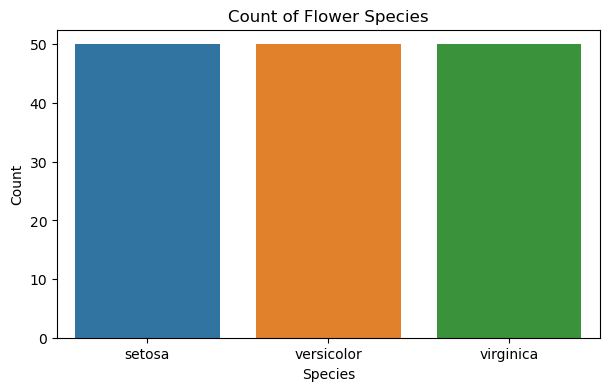

In [7]:
# Count the number of samples in each species
species_counts = df["species_name"].value_counts()
print(species_counts)

# Plot class distribution
plt.figure(figsize=(7, 4))
sns.countplot(x="species_name", data=df)
plt.title("Count of Flower Species")
plt.xlabel("Species")
plt.ylabel("Count")
plt.show()

## Step 6: Visualize Feature Relationships

We use pairplots to see how the flower measurements differ across species.

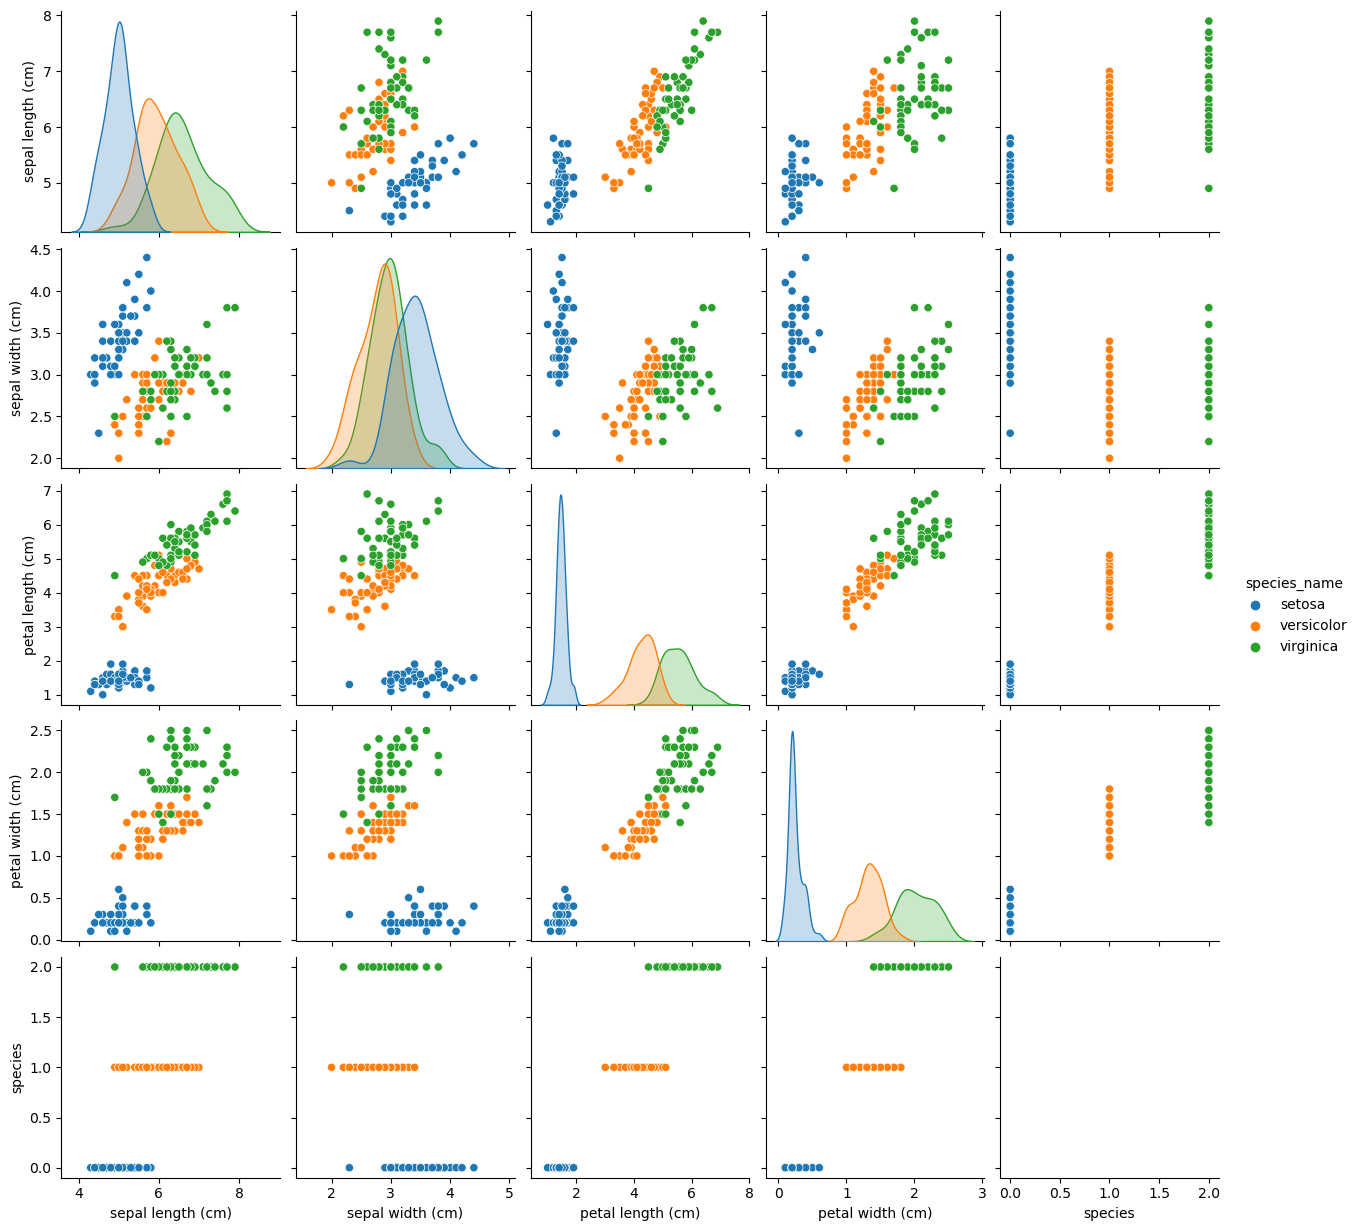

In [8]:
# Pairplot helps visualize relationships among features
sns.pairplot(df, hue="species_name")
plt.show()

## Step 7: Select Input Features and Target Variable

### Input Features (X)
- sepal length
- sepal width
- petal length
- petal width

### Target Variable (y)
- species

In [9]:
# Select input features
X = df[iris.feature_names]

# Select target column
y = df["species"]

# Display first 5 rows of X
print("Input Features (X):")
print(X.head())

# Display first 5 rows of y
print("\nTarget Variable (y):")
print(y.head())

Input Features (X):
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2

Target Variable (y):
0    0
1    0
2    0
3    0
4    0
Name: species, dtype: int32


## Step 8: Split the Dataset into Training and Testing Sets

### Why do we split?
- Training data is used to train the model
- Testing data is used to evaluate model performance on unseen data

In [10]:
# Split dataset into 80% training data and 20% testing data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Print shapes of split datasets
print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

X_train shape: (120, 4)
X_test shape : (30, 4)
y_train shape: (120,)
y_test shape : (30,)


## Step 9: Train Logistic Regression Model

Logistic Regression is used for classification problems.
Here, the model learns how feature values relate to flower species.

In [11]:
# Create Logistic Regression model
# max_iter is increased to avoid convergence warnings
model = LogisticRegression(max_iter=200)

# Train the model using training data
model.fit(X_train, y_train)

print("Model training completed successfully.")

Model training completed successfully.


## Step 10: Make Predictions

Now we use the trained model to predict flower species for the test data.

In [12]:
# Predict class labels for test data
y_pred = model.predict(X_test)

# Predict probabilities for each class
y_pred_proba = model.predict_proba(X_test)

# Display first 10 predictions
print("First 10 predicted labels:")
print(y_pred[:10])

print("\nFirst 10 actual labels:")
print(y_test.values[:10])

print("\nPredicted probabilities for first 5 test samples:")
print(y_pred_proba[:5])

First 10 predicted labels:
[0 2 1 1 0 1 0 0 2 1]

First 10 actual labels:
[0 2 1 1 0 1 0 0 2 1]

Predicted probabilities for first 5 test samples:
[[9.85316588e-01 1.46833654e-02 4.62316524e-08]
 [1.37666781e-03 3.90929049e-01 6.07694283e-01]
 [1.86889185e-01 8.08907952e-01 4.20286300e-03]
 [1.55859311e-01 8.39910916e-01 4.22977306e-03]
 [9.88257309e-01 1.17426558e-02 3.53985366e-08]]


## Step 11: Model Accuracy

Accuracy tells us the proportion of correct predictions.

In [13]:
# Compute accuracy score
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy of Logistic Regression model:", accuracy)

Accuracy of Logistic Regression model: 0.9666666666666667


## Step 12: Confusion Matrix

A confusion matrix shows:
- correct predictions
- wrong predictions
for each class

Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]


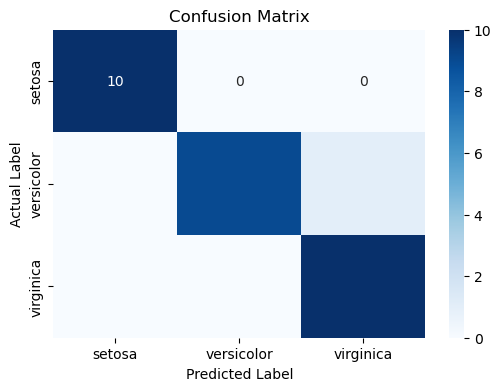

In [14]:
# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

# Visualize confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

## Step 13: Classification Report

This report provides:
- Precision
- Recall
- F1-score
- Support

for each flower species

In [15]:
# Print classification report
report = classification_report(y_test, y_pred, target_names=iris.target_names)
print("Classification Report:")
print(report)

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



## Step 14: Understand Model Coefficients

Logistic Regression learns coefficients for each feature.
These coefficients help us understand which measurements influence classification.

In [16]:
# Create a DataFrame for model coefficients
coef_df = pd.DataFrame(
    model.coef_,
    columns=iris.feature_names,
    index=iris.target_names
)

print("Model Coefficients:")
print(coef_df)

Model Coefficients:
            sepal length (cm)  sepal width (cm)  petal length (cm)  \
setosa              -0.529655          0.827403          -2.347212   
versicolor           0.529736         -0.304934          -0.170972   
virginica           -0.000082         -0.522469           2.518184   

            petal width (cm)  
setosa             -0.993498  
versicolor         -0.856199  
virginica           1.849697  


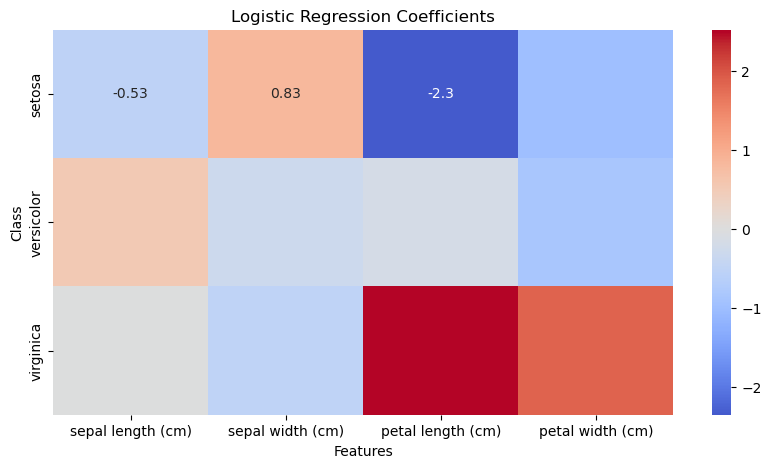

In [17]:
# Visualize coefficients
plt.figure(figsize=(10, 5))
sns.heatmap(coef_df, annot=True, cmap="coolwarm", center=0)
plt.title("Logistic Regression Coefficients")
plt.xlabel("Features")
plt.ylabel("Class")
plt.show()

## Step 15: Predict Species for a New Flower

We can test the model on a manually entered flower measurement.

In [18]:
# Example new flower input:
# [sepal length, sepal width, petal length, petal width]
new_flower = [[5.1, 3.5, 1.4, 0.2]]

# Predict class label
predicted_class = model.predict(new_flower)[0]

# Predict class probabilities
predicted_probabilities = model.predict_proba(new_flower)[0]

print("Predicted class label:", predicted_class)
print("Predicted species name:", iris.target_names[predicted_class])
print("Predicted probabilities:", predicted_probabilities)

Predicted class label: 0
Predicted species name: setosa
Predicted probabilities: [9.78399795e-01 2.16001497e-02 5.50876351e-08]


C:\Users\CHARUSAT\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
C:\Users\CHARUSAT\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


## Step 16: Final Conclusion

### What we learned
- IRIS dataset is a classification dataset
- Logistic Regression can classify flowers into species
- The model uses flower measurements as input features
- Accuracy and confusion matrix help evaluate performance
- Coefficients help understand the influence of each feature

### One-line summary
This notebook uses Logistic Regression to classify flowers in the IRIS dataset based on sepal and petal measurements.

## Practical-8 Submission Section (Minimum Required)

This section uses Titanic training data and includes:
- Cleaning and encoding
- Logistic regression model training
- Accuracy, confusion matrix, classification report, ROC-AUC

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve

sns.set(style="whitegrid")

df = pd.read_csv("titanic_disaster/train.csv")
print("Dataset shape:", df.shape)

# Select practical feature set
cols = ["Survived", "Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked"]
df = df[cols].copy()

# Missing value handling
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Encoding
sex_map = {"male": 0, "female": 1}
emb_map = {"S": 0, "C": 1, "Q": 2}
df["Sex"] = df["Sex"].map(sex_map)
df["Embarked"] = df["Embarked"].map(emb_map)
df = df.dropna()

X = df.drop(columns=["Survived"])
y = df["Survived"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print("Accuracy:", round(acc, 4))
print("\nConfusion Matrix:")
print(cm)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("ROC-AUC:", round(auc, 4))

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()

coef_table = pd.DataFrame({"Feature": X.columns, "Coefficient": model.coef_[0]}).sort_values("Coefficient", ascending=False)
print("\nFeature coefficients:")
display(coef_table)

print("\nConclusion (minimum):")
print("Positive coefficients increase survival odds; negative coefficients decrease survival odds.")